In [26]:

import pandas as pd
data = pd.read_csv("D:/PROJECTS/Air_Watch/Data/Global_dataset.csv")
data.head()

,Date,City,Latitude,Longitude,PM2.5,PM10,NO2,SO2,CO,Ozone,Aerosol_Optical_Depth,AQI_Class
0,2025-11-08 00:00:00,"Lahore, Pakistan",31.5497,74.3436,81.0,82.7,94.0,16.4,1910.0,11.0,0.19,Unhealthy
1,2025-11-08 01:00:00,"Lahore, Pakistan",31.5497,74.3436,78.2,79.6,90.9,14.4,1413.0,10.0,0.19,Unhealthy
2,2025-11-08 02:00:00,"Lahore, Pakistan",31.5497,74.3436,75.4,76.8,85.0,12.8,1060.0,12.0,0.19,Unhealthy
3,2025-11-08 03:00:00,"Lahore, Pakistan",31.5497,74.3436,72.2,73.6,72.8,11.8,863.0,20.0,0.19,Unhealthy
4,2025-11-08 04:00:00,"Lahore, Pakistan",31.5497,74.3436,69.8,71.2,57.7,11.1,811.0,31.0,0.19,Unhealthy



# Understanding the Data

In [27]:
print("<<----- info ---->>")
print(data.info())
print("<<--- describe -->>")
print(data.describe())
print("<< -- NULL value  -->>")
print(data.isnull().sum())

<<----- info ---->>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17472 entries, 0 to 17471
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   17472 non-null  object 
 1   City                   17472 non-null  object 
 2   Latitude               17472 non-null  float64
 3   Longitude              17472 non-null  float64
 4   PM2.5                  17472 non-null  float64
 5   PM10                   17472 non-null  float64
 6   NO2                    17472 non-null  float64
 7   SO2                    17472 non-null  float64
 8   CO                     17472 non-null  float64
 9   Ozone                  17472 non-null  float64
 10  Aerosol_Optical_Depth  17472 non-null  float64
 11  AQI_Class              17472 non-null  object 
dtypes: float64(9), object(3)
memory usage: 1.6+ MB
None
<<--- describe -->>
           Latitude     Longitude         PM2.5          PM10     

# No Null value


In [28]:
data.rename(columns={
    "Date": "date",
    "City": "city",
    "AQI_Class": "AQI_category"
}, inplace=True)

data["date"] = pd.to_datetime(data["date"])

data["month"] = data["date"].dt.month
data["year"] = data["date"].dt.year
data["day"] = data["date"].dt.day

data = data.drop_duplicates()

mapping = {
    "Good": 1,
    "Moderate": 2,
    "Unhealthy": 3
}

data["AQI_level"] = data["AQI_category"].map(mapping)
print("<<-- Rename Data Info -->>")
print(data.info())
print("First 5 row")
print(data.head())

data.to_csv("../data/processed/clean_data.csv", index=False)

<<-- Rename Data Info -->>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17472 entries, 0 to 17471
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   17472 non-null  datetime64[ns]
 1   city                   17472 non-null  object        
 2   Latitude               17472 non-null  float64       
 3   Longitude              17472 non-null  float64       
 4   PM2.5                  17472 non-null  float64       
 5   PM10                   17472 non-null  float64       
 6   NO2                    17472 non-null  float64       
 7   SO2                    17472 non-null  float64       
 8   CO                     17472 non-null  float64       
 9   Ozone                  17472 non-null  float64       
 10  Aerosol_Optical_Depth  17472 non-null  float64       
 11  AQI_category           17472 non-null  object        
 12  month                  17472 non-

# Handling outliers

In [29]:
Q1 = data["AQI_level"].quantile(0.25)
Q3 = data["AQI_level"].quantile(0.75)
IQR = Q3 - Q1

data = data[(data["AQI_level"] >= Q1 - 1.5*IQR) & (data["AQI_level"] <= Q3 + 1.5*IQR)]
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 13831 entries, 0 to 17471
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   13831 non-null  datetime64[ns]
 1   city                   13831 non-null  object        
 2   Latitude               13831 non-null  float64       
 3   Longitude              13831 non-null  float64       
 4   PM2.5                  13831 non-null  float64       
 5   PM10                   13831 non-null  float64       
 6   NO2                    13831 non-null  float64       
 7   SO2                    13831 non-null  float64       
 8   CO                     13831 non-null  float64       
 9   Ozone                  13831 non-null  float64       
 10  Aerosol_Optical_Depth  13831 non-null  float64       
 11  AQI_category           13831 non-null  object        
 12  month                  13831 non-null  int32         
 13  year  

In [30]:
import os
data["date"] = pd.to_datetime(data["date"])

data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day

os.makedirs("../Data/processed", exist_ok=True)
data.to_csv("../Data/processed/clean_data.csv", index=False)

In [31]:
print(data['AQI_category'].value_counts())

AQI_category
Unhealthy    5970
Good         4032
Moderate     3829
Name: count, dtype: int64


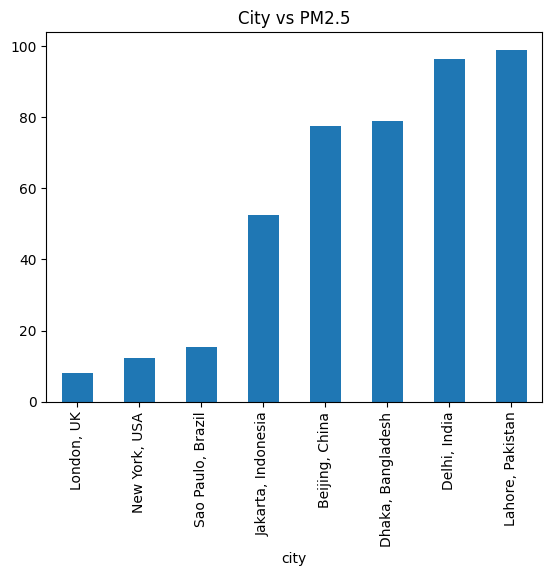

In [32]:
import matplotlib.pyplot as plt 
import seaborn as sns
data.groupby('city')['PM2.5'].mean().sort_values().plot(kind='bar')
plt.title("City vs PM2.5")
plt.show()

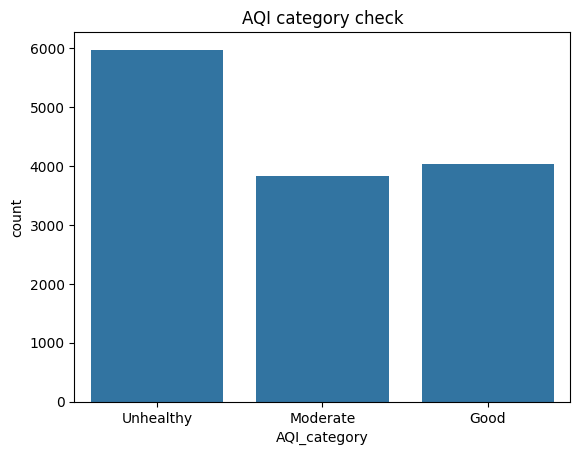

In [33]:


sns.countplot(x=data['AQI_category'],data=data)
plt.title("AQI category check")
plt.show()

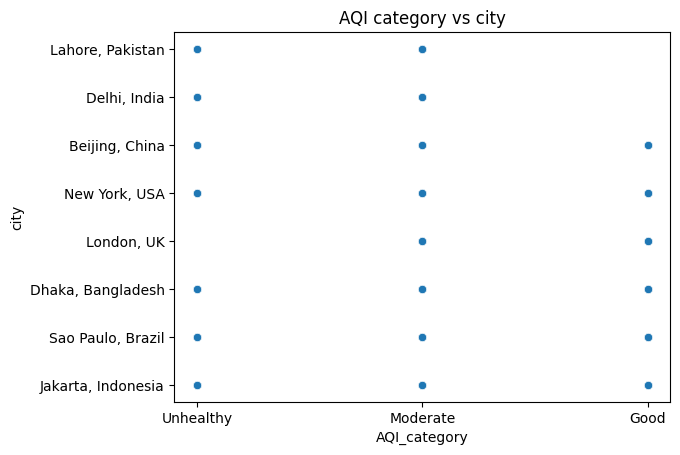

In [34]:
sns.scatterplot(x=data['AQI_category'],y=data['city'],data=data)
plt.title("AQI category vs city")
plt.show()

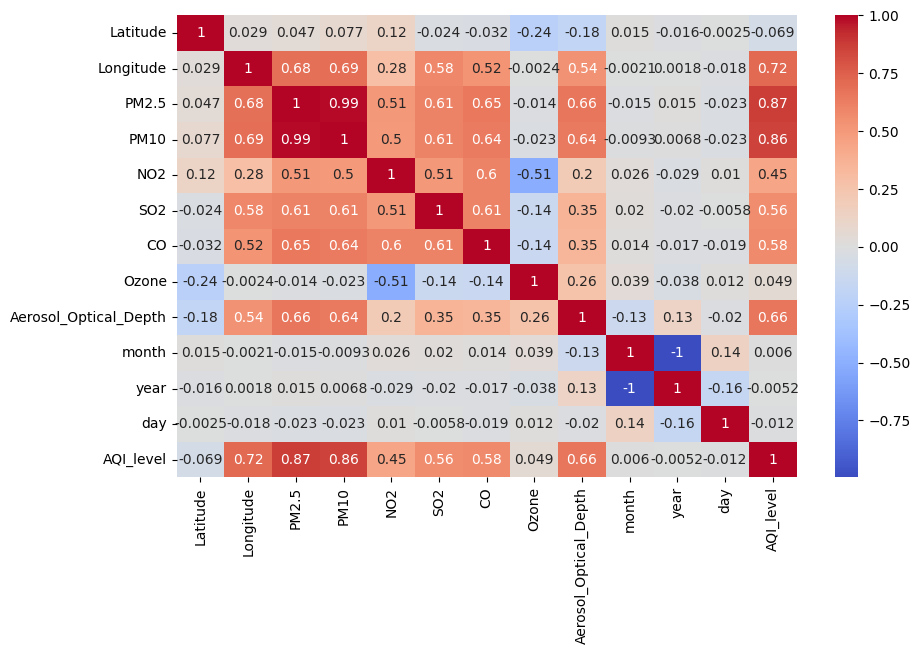

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


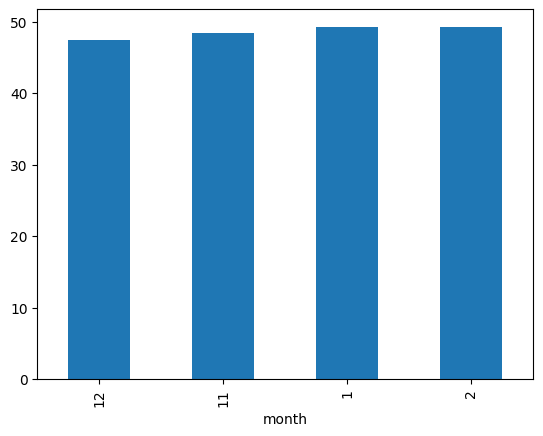

In [40]:
data.groupby('month')['PM2.5'].mean().sort_values().plot(kind='bar')
plt.show()